In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

base_dir = "fj_model_results"

years = []
scores = []
baselines = []
finals = []

for year in range(2018, 2025):
    file_path = os.path.join(base_dir, f"{year}_results.pickle")
    
    with open(file_path, "rb") as f:
        results = pickle.load(f)
    
    years.append(year)
    scores.append(np.mean(results["scores"]))       # aggregate per year
    baselines.append(np.mean(results["x_baseline"]))
    finals.append(np.mean(results["x_final"]))

years = np.array(years)
scores = np.array(scores)
baselines = np.array(baselines)
finals = np.array(finals)

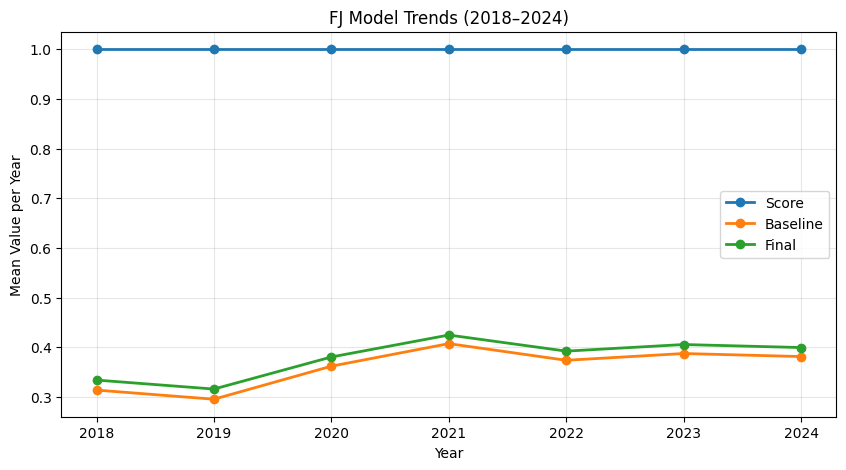

In [3]:
plt.figure(figsize=(10, 5))

plt.plot(years, scores, marker='o', linewidth=2, label='Score')
plt.plot(years, baselines, marker='o', linewidth=2, label='Baseline')
plt.plot(years, finals, marker='o', linewidth=2, label='Final')

plt.title("FJ Model Trends (2018–2024)")
plt.xlabel("Year")
plt.ylabel("Mean Value per Year")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

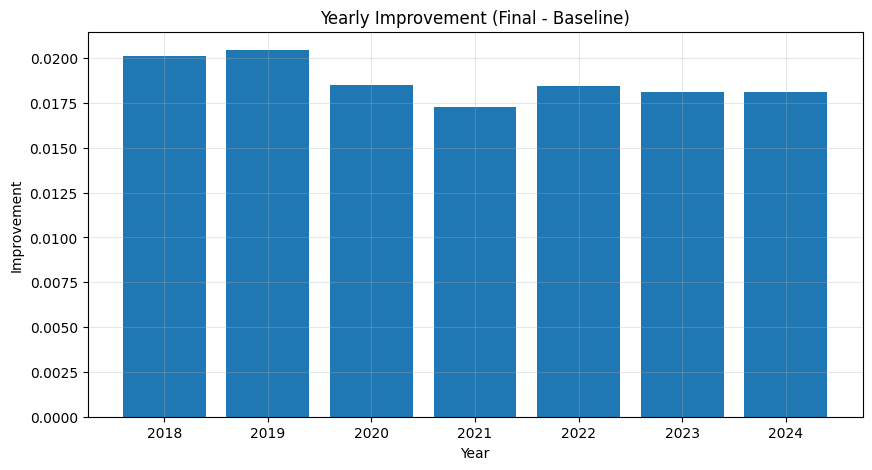

In [4]:
improvement = finals - baselines

plt.figure(figsize=(10, 5))

plt.bar(years, improvement)

plt.title("Yearly Improvement (Final - Baseline)")
plt.xlabel("Year")
plt.ylabel("Improvement")
plt.grid(True, alpha=0.3)
plt.show()

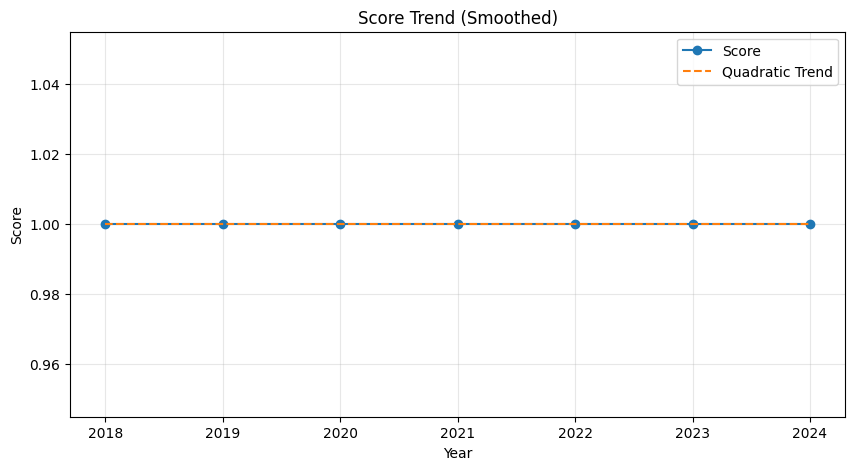

In [5]:
z = np.polyfit(years, scores, 2)
trend = np.poly1d(z)(years)

plt.figure(figsize=(10, 5))
plt.plot(years, scores, marker='o', label='Score')
plt.plot(years, trend, linestyle='--', label='Quadratic Trend')

plt.title("Score Trend (Smoothed)")
plt.xlabel("Year")
plt.ylabel("Score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()